# DETR UI Component Detection Training

Welcome to the DETR (DEtection TRansformer) training notebook! In this notebook, we will:
1. **Load and inspect** the real-life `mrtoy/mobile-ui-design` dataset.
2. **Visualize** the dataset samples and bounding boxes.
3. **Prepare a PyTorch Dataset** wrapper formatted for DETR.
4. **Fine-tune DETR** (`facebook/detr-resnet-50`) on the dataset.
5. **Evaluate** the model's predictions on new UI screenshots.

## Step 1: Load and Inspect the Dataset

First, let's import the Hugging Face `datasets` library and load our dataset.

In [1]:
from datasets import load_dataset

print("Loading dataset...")
dataset = load_dataset("mrtoy/mobile-ui-design")
print("\nDataset splits:")
print(dataset)

print("\nFirst sample structure:")
sample = dataset["train"][0]
for key, val in sample.items():
    if key == "image":
        print(f"- image: PIL.Image of size {val.size}")
    else:
        print(f"- {key}: {type(val)} = {val}")

c:\Users\aadar\Desktop\ml\ui reviewer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset...


c:\Users\aadar\Desktop\ml\ui reviewer\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aadar\.cache\huggingface\hub\datasets--mrtoy--mobile-ui-design. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 100%|██████████| 7846/7846 [00:08<00:00, 948.98 examples/s] 



Dataset splits:
DatasetDict({
    train: Dataset({
        features: ['width', 'height', 'image', 'objects'],
        num_rows: 7846
    })
})

First sample structure:
- width: <class 'int'> = 375
- height: <class 'int'> = 667
- image: PIL.Image of size (375, 667)
- objects: <class 'dict'> = {'bbox': [[0.0, 0.0, 375.0, 667.0], [0.0, 0.0, 375.0, 20.0], [0.0, 0.0, 375.0, 112.0], [0.0, 0.0, 375.0, 20.0], [8.0, 30.0, 349.0, 312.0], [212.0, 45.0, 88.0, 28.0], [134.0, 30.0, 108.0, 21.0], [335.0, 31.0, 22.0, 22.0], [29.0, 80.0, 317.0, 19.0], [17.0, 107.0, 98.0, 5.0], [8.0, 153.0, 153.0, 189.0], [8.0, 153.0, 153.0, 170.0], [52.0, 303.0282685512368, 103.0, 19.0], [50.0, 167.0, 111.0, 111.0], [94.25949367088606, 237.66525025719005, 36.53164556962027, 20.0], [73.18354430379759, 198.48937692892605, 74.46835443037975, 41.0], [60.5, 326.4487632508834, 65.5, 16.0], [198.0, 156.0, 145.0, 185.0], [198.0, 156.0, 145.0, 185.0], [217.5, 167.028880866426, 113.0, 111.0], [217.5, 167.028880866426, 113.0, 11

## Step 2: Visualize Bounding Boxes

Let's write a function to draw the bounding boxes on the UI image so we can inspect how the annotations look.

Objects in first sample: {'bbox': [[0.0, 0.0, 375.0, 667.0], [0.0, 0.0, 375.0, 20.0], [0.0, 0.0, 375.0, 112.0], [0.0, 0.0, 375.0, 20.0], [8.0, 30.0, 349.0, 312.0], [212.0, 45.0, 88.0, 28.0], [134.0, 30.0, 108.0, 21.0], [335.0, 31.0, 22.0, 22.0], [29.0, 80.0, 317.0, 19.0], [17.0, 107.0, 98.0, 5.0], [8.0, 153.0, 153.0, 189.0], [8.0, 153.0, 153.0, 170.0], [52.0, 303.0282685512368, 103.0, 19.0], [50.0, 167.0, 111.0, 111.0], [94.25949367088606, 237.66525025719005, 36.53164556962027, 20.0], [73.18354430379759, 198.48937692892605, 74.46835443037975, 41.0], [60.5, 326.4487632508834, 65.5, 16.0], [198.0, 156.0, 145.0, 185.0], [198.0, 156.0, 145.0, 185.0], [217.5, 167.028880866426, 113.0, 111.0], [217.5, 167.028880866426, 113.0, 111.0], [255.12179487179492, 235.8523511401545, 38.37820512820508, 20.0], [250.8461538461538, 197.48375451263541, 79.65384615384622, 41.0], [211.0, 302.0, 132.0, 19.0], [224.0, 325.0, 106.0, 16.0], [15.0, 396.0, 341.0, 268.0], [9.0, 425.0, 358.0, 13.0], [9.0, 426.0, 6.0,

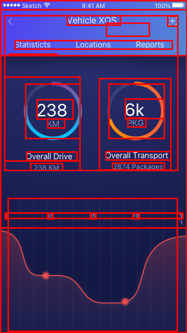

In [ ]:
from PIL import ImageDraw

# Let's check the first sample
sample = dataset["train"][0]
img = sample["image"].copy()
draw = ImageDraw.Draw(img)
objects = sample["objects"]

print("Objects in first sample:", objects)


# Draw the boxes
# Note: Let's check if bboxes are [xmin, ymin, width, height] or [xmin, ymin, xmax, ymax]
# And check if they are absolute pixels or normalized [0, 1].
for bbox, cat_id in zip(objects["bbox"], objects["category"]):
    # Standard COCO format is [xmin, ymin, width, height]
    # If they are absolute pixels:
    x1, y1, w, h = bbox
    x2, y2 = x1 + w, y1 + h
    
    draw.rectangle([x1, y1, x2, y2], outline="red", width=3)

print("Displaying image with bounding boxes:")
img.resize((img.width // 2, img.height // 2))  # Resize to fit in the notebook display